In a small 3x3 grid, an agent must find a hidden treasure. The agent can move in four
directions (up, down, left, right) and should avoid walls (cells it cannot pass). Use SARSA to
learn the best strategy to find the treasure.
Requirements:

> Define the environment with the grid, walls, and a treasure location.

> Implement SARSA to teach the agent to reach the treasure.

> Experiment with different learning rates and exploration strategies.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

Define the environment with the grid, walls, and a treasure location.


In [ ]:
# grid:
size = 3
start = (0, 0)
treasure = (2, 2)

# wall:
walls = [(1, 1)]

# actions:
actions = ['up', 'down', 'left', 'right']
moves = {
    'up': (-1, 0), 'down': (1, 0), 'left': (0, -1), 'right': (0, 1)
    }

In [ ]:
# checking position:
def is_valid(position):

  if position[0] < 0 or position[0] >= size or position[1] < 0 or position[1] >= size:
    return False

  if position in walls:
    return False

  return True

In [ ]:
# move agent:
def step(state, action):
  move = moves[action]
  next_state = (state[0] + move[0], state[1] + move[1])

  # wall or outside grid:
  if not is_valid(next_state):
    return (state, -5, False)

  # treasure:
  if next_state == treasure:
    return (next_state, 20, True)

  # normal movement:
  return (next_state, -1, False)

In [ ]:
# choose action:
def choose_action(Q, state, epsilon):

  # explore:
  if random.random() < epsilon:
    return random.choice(actions)

  # exploit:
  row, col = state
  return actions[np.argmax(Q[row, col])]

Implement SARSA to teach the agent to reach the treasure.

In [ ]:
# use different alphas:
alphas = [0.1, 0.3, 0.5, 0.7]
alpha_results = {}

for alpha in alphas:
  Q, rewards = train_sarsa(alpha=alpha, epsilon=1.0, decay=0.99)
  alpha_results[alpha] = (Q, rewards)
  print("Alpha =", alpha,", Average Reward =", np.mean(rewards[-30:]))

Alpha = 0.1 , Average Reward = 15.833333333333334
Alpha = 0.3 , Average Reward = 16.533333333333335
Alpha = 0.5 , Average Reward = 16.766666666666666
Alpha = 0.7 , Average Reward = 16.666666666666668


In [ ]:
def train_sarsa(alpha, epsilon, decay):
  Q = np.zeros((size, size, 4))
  gamma = 0.9
  rewards = []

  for episode in range(300):
    state = start

    # first action:
    action = choose_action(Q, state, epsilon)
    total_reward = 0
    for i in range(50):

      # take action
      next_state, reward, done = step(state, action)

      # choose next action
      next_action = choose_action(Q, next_state, epsilon)

      # current state
      r, c = state
      action_index = actions.index(action)

      # next state
      nr, nc = next_state
      next_action_index = actions.index(next_action)

      # sarsa update
      Q[r, c, action_index] = Q[r, c, action_index] + alpha * (reward + gamma * Q[nr, nc, next_action_index] - Q[r, c, action_index])

      # move forward
      state = next_state
      action = next_action
      total_reward += reward
      if done:
        break

    # decay epsilon
    epsilon = max(0.05, epsilon * decay)
    rewards.append(total_reward)
  return Q, rewards

Experiment with different learning rates and exploration strategies.


In [ ]:
# use different epsilons:
epsilons = [1.0, 0.5, 0.75, 0.1]
epsilon_results = {}

for epsilon in epsilons:
  Q, rewards = train_sarsa(alpha=0.3, epsilon=epsilon, decay=1.0)
  epsilon_results[epsilon] = (Q, rewards)

  print(
      "Epsilon =", epsilon, ", Average Reward =", np.mean(rewards[-30:])
  )

Epsilon = 1.0 , Average Reward = -80.4
Epsilon = 0.5 , Average Reward = 7.366666666666666
Epsilon = 0.75 , Average Reward = -7.333333333333333
Epsilon = 0.1 , Average Reward = 15.5


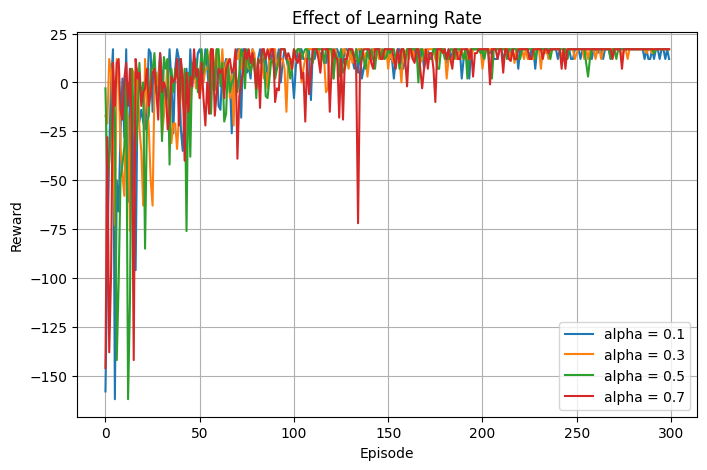

In [ ]:
# plot learning rate comparison:
plt.figure(figsize=(8, 5))
for alpha in alphas:
  Q, rewards = alpha_results[alpha]
  plt.plot(rewards, label="alpha = " + str(alpha))

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid()
plt.show()

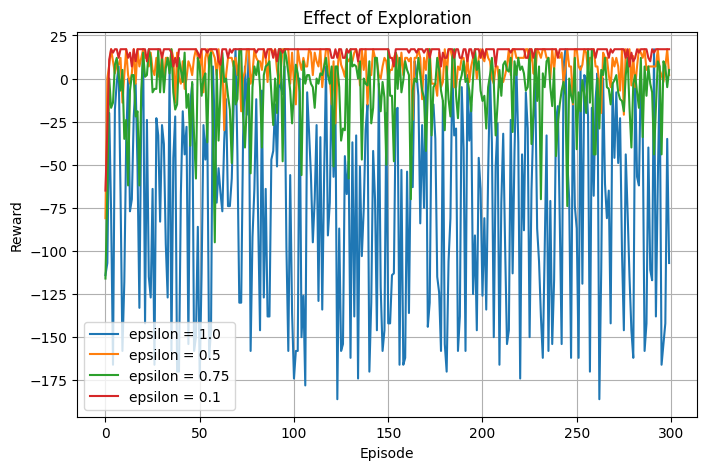

In [ ]:
# plot exploration comparison:
plt.figure(figsize=(8, 5))

for epsilon in epsilons:
  Q, rewards = epsilon_results[epsilon]
  plt.plot(rewards, label="epsilon = " + str(epsilon))

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Effect of Exploration")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# learning path:
Q = alpha_results[0.1][0]
state = start
path = [state]

for i in range(20):
  row, col = state
  # best action:
  action = actions[np.argmax(Q[row, col])]
  next_state, reward, done = step(state, action)

  # stop if stuck:
  if next_state == state:
    break
  path.append(next_state)
  state = next_state
  if done:
    break

print("Learned Path:", path)
print("\nNumber of Steps:", len(path)-1)

Learned Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]

Number of Steps: 4
